# Лабораторная работа 16

Тема: **Vision Transformer (ViT) для классификации изображений CIFAR-10**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваши ожидания от ViT в сравнении с CNN

В Лабораторной работе 8 мы решали задачу классификации CIFAR-10 с помощью свёрточных сетей (CNN). Теперь мы применим архитектуру, изначально созданную для текстов (Transformer).

Перед началом работы зафиксируйте своё понимание (6-10 предложений):

1. В чем главное отличие того, как CNN и ViT «смотрят» на картинку? (Вспомните про локальные признаки в свертках и глобальное внимание в Трансформерах).
2. Зачем изображение нарезается на непересекающиеся "патчи" (patches), а не подается в Трансформер попиксельно?
3. Ожидаете ли вы, что простой самодельный ViT побьет вашу CNN из 8-й лабораторной при обучении "с нуля" на небольшом датасете? Почему?

In [1]:
intro_text = """
1. CNN смотрит на картинку локально - фильтр скользит по небольшим областям
и ищет края, текстуры, формы. Это встроенное предположение что соседние
пиксели связаны. ViT смотрит глобально - каждый патч сразу взаимодействует
со всеми другими патчами через механизм внимания. CNN нужно много слоёв чтобы
"увидеть" всю картинку, ViT видит её целиком с первого слоя.

2. Попиксельно подавать нельзя - для CIFAR-10 32x32=1024 токена, это медленно
и дорого. Патчи 4x4 или 8x8 сжимают картинку до 64 или 16 токенов - разумный
компромисс между детальностью и скоростью. Каждый патч как одно "слово" для
трансформера.

3. Не ожидаю что простой ViT побьёт CNN на CIFAR-10 с нуля. CNN имеет
встроенное индуктивное смещение - локальность и инвариантность к сдвигу -
которое идеально подходит для изображений. ViT не имеет этих предположений
и требует намного больше данных чтобы выучить их самостоятельно. На маленьком
датасете CNN выигрывает, ViT берёт своё только на ImageNet-масштабах.
"""
print(intro_text)


1. CNN смотрит на картинку локально - фильтр скользит по небольшим областям
и ищет края, текстуры, формы. Это встроенное предположение что соседние
пиксели связаны. ViT смотрит глобально - каждый патч сразу взаимодействует
со всеми другими патчами через механизм внимания. CNN нужно много слоёв чтобы
"увидеть" всю картинку, ViT видит её целиком с первого слоя.

2. Попиксельно подавать нельзя - для CIFAR-10 32x32=1024 токена, это медленно
и дорого. Патчи 4x4 или 8x8 сжимают картинку до 64 или 16 токенов - разумный
компромисс между детальностью и скоростью. Каждый патч как одно "слово" для
трансформера.

3. Не ожидаю что простой ViT побьёт CNN на CIFAR-10 с нуля. CNN имеет
встроенное индуктивное смещение - локальность и инвариантность к сдвигу -
которое идеально подходит для изображений. ViT не имеет этих предположений
и требует намного больше данных чтобы выучить их самостоятельно. На маленьком
датасете CNN выигрывает, ViT берёт своё только на ImageNet-масштабах.



## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги, аналогичные Лабораторной 8.

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Ваш личный seed (заполните его, можно взять тот же, что в Лаб 8)
MY_SEED = 37
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 37


## 3. CIFAR‑10: загрузка и нормализация

Используем те же параметры нормализации, что и для CNN.

In [3]:
batch_size = 128  # при выполнении работы попробуйте изменить

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

100%|██████████| 170M/170M [00:02<00:00, 75.3MB/s]


Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000


### Краткий комментарий по данным

В Лабораторной 8 вы уже описывали датасет. Сейчас ответьте на другой вопрос (3-5 предложений):
Размер картинок в CIFAR-10 — 32x32 пикселя. Если мы выберем размер патча для ViT равным 8x8, на сколько токенов (патчей) будет разбита одна картинка? А если размер патча будет 16x16? Хватит ли Трансформеру такого количества токенов для понимания смысла картинки?

In [4]:
data_comment = """
При патче 8x8: картинка 32x32 делится на (32/8)x(32/8) = 4x4 = 16 токенов.
При патче 16x16: (32/16)x(32/16) = 2x2 = 4 токена - очень грубо.

16 токенов (патч 8x8) - минимально приемлемо для CIFAR-10. Каждый патч
содержит 8x8x3=192 пикселя - достаточно информации внутри патча, но
глобальных взаимодействий всего 16 - мало для сложных объектов.

4 токена (патч 16x16) - слишком грубо, каждый патч это четверть картинки.
Трансформер не сможет различить детали - кошка и собака будут выглядеть
похоже на таком уровне детализации.
"""
print(data_comment)


При патче 8x8: картинка 32x32 делится на (32/8)x(32/8) = 4x4 = 16 токенов.
При патче 16x16: (32/16)x(32/16) = 2x2 = 4 токена - очень грубо.

16 токенов (патч 8x8) - минимально приемлемо для CIFAR-10. Каждый патч
содержит 8x8x3=192 пикселя - достаточно информации внутри патча, но
глобальных взаимодействий всего 16 - мало для сложных объектов.

4 токена (патч 16x16) - слишком грубо, каждый патч это четверть картинки.
Трансформер не сможет различить детали - кошка и собака будут выглядеть
похоже на таком уровне детализации.



## 4. Архитектура Vision Transformer

В этой лабораторной мы пишем **Micro-ViT**. Картинка превращается в последовательность векторов с помощью свертки (Patch Embedding), к ней добавляется позиционное кодирование и специальный `[CLS]` токен, после чего всё это обрабатывается стандартным Transformer Encoder.

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, embed_dim=64, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        # Считаем количество патчей. Для 32x32 и патча 8x8 это (32/8) * (32/8) = 16
        self.num_patches = (img_size // patch_size) ** 2

        # Свертка без перекрытий: размер ядра и шаг равны размеру патча
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (B, C, H, W)
        x = self.proj(x)           # -> (B, embed_dim, H/P, W/P)
        x = x.flatten(2)           # -> (B, embed_dim, num_patches)
        x = x.transpose(1, 2)      # -> (B, num_patches, embed_dim)
        return x

class SimpleViT(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, embed_dim=64, img_size=32, num_classes=10, depth=2, heads=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim, img_size)

        # [CLS] токен (обучаемый параметр)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Обучаемые позиционные эмбеддинги (длина = количество патчей + 1 для CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))

        # Блок Трансформера
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Итоговый классификатор
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        # 1. Извлекаем патчи
        x = self.patch_embed(x)                        # (B, num_patches, embed_dim)

        # 2. Добавляем [CLS] токен
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)          # (B, num_patches + 1, embed_dim)

        # 3. Добавляем позиционное кодирование
        x = x + self.pos_embed

        # 4. Пропускаем через Transformer
        x = self.transformer(x)

        # 5. Классификация по выходу [CLS] токена (индекс 0)
        cls_out = x[:, 0]
        return self.mlp_head(cls_out)

patch_size = 8
embed_dim = 96
depth = 3
heads = 4

model = SimpleViT(patch_size=patch_size, embed_dim=embed_dim, depth=depth, heads=heads).to(device)
print(model)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")

SimpleViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 96, kernel_size=(8, 8), stride=(8, 8))
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=96, out_features=10, bias=True)
  )
)
Количество параметров: 356938


### Ваш комментарий к архитектуре

Ответьте коротко:

- Для чего в архитектуру внедрен обучаемый `[CLS]` токен и почему мы передаем в финальный `nn.Linear` именно его, а не усредненные значения всех патчей?
- В CNN (Лабораторная 8) мы не использовали Positional Encoding. Почему здесь он жизненно необходим?

In [6]:
arch_comment = """
CLS токен - это специальный обучаемый вектор который не соответствует ни
одному патчу. Через механизм внимания он собирает информацию от всех патчей
и к концу трансформера содержит глобальное представление всего изображения.
Мы берём именно его потому что он обучен агрегировать информацию для
классификации, тогда как усреднение патчей даёт менее целенаправленное
представление.

Без Positional Encoding трансформер не знает где находится каждый патч -
патч с носом кошки в левом углу и в правом углу будут неразличимы. Получится
bag of patches - набор кусочков без пространственной структуры. В CNN
позиционная информация встроена автоматически через локальность свёртки -
фильтр знает своё положение на карте признаков. В ViT этого нет, поэтому
PE обязателен.
"""
print(arch_comment)


CLS токен - это специальный обучаемый вектор который не соответствует ни
одному патчу. Через механизм внимания он собирает информацию от всех патчей
и к концу трансформера содержит глобальное представление всего изображения.
Мы берём именно его потому что он обучен агрегировать информацию для
классификации, тогда как усреднение патчей даёт менее целенаправленное
представление.

Без Positional Encoding трансформер не знает где находится каждый патч -
патч с носом кошки в левом углу и в правом углу будут неразличимы. Получится
bag of patches - набор кусочков без пространственной структуры. В CNN
позиционная информация встроена автоматически через локальность свёртки -
фильтр знает своё положение на карте признаков. В ViT этого нет, поэтому
PE обязателен.



## 5. Функция потерь, оптимизатор и цикл обучения

Здесь код практически идентичен Лабораторной 8. ViT чувствителен к скорости обучения (learning rate), поэтому используем AdamW (рекомендованный для ViT) вместо обычного Adam.

In [7]:
criterion = nn.CrossEntropyLoss()
learning_rate = 5e-4  # чуть меньше чем 1e-3 - стабильнее для ViT
# Для ViT AdamW часто работает лучше обычного Adam за счет правильной регуляризации весов
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for images, labels in tqdm(dataloader, desc="Обучение", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Клиппинг градиентов помогает стабилизировать обучение Трансформеров
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

## 6. Обучение базовой модели

Запустим обучение на 5 эпох. Из-за малого размера модели одна эпоха на ЦПУ должна обучаться меньше 1 минуты (около 30 сек).

Эпоха 1/5 | Train Loss: 1.8279, Acc: 0.3237 | Test Loss: 1.6467, Acc: 0.3886


Эпоха 2/5 | Train Loss: 1.5823, Acc: 0.4151 | Test Loss: 1.5084, Acc: 0.4545


Эпоха 3/5 | Train Loss: 1.4473, Acc: 0.4701 | Test Loss: 1.3897, Acc: 0.4957


Эпоха 4/5 | Train Loss: 1.3346, Acc: 0.5154 | Test Loss: 1.2970, Acc: 0.5281


Эпоха 5/5 | Train Loss: 1.2520, Acc: 0.5452 | Test Loss: 1.2570, Acc: 0.5444


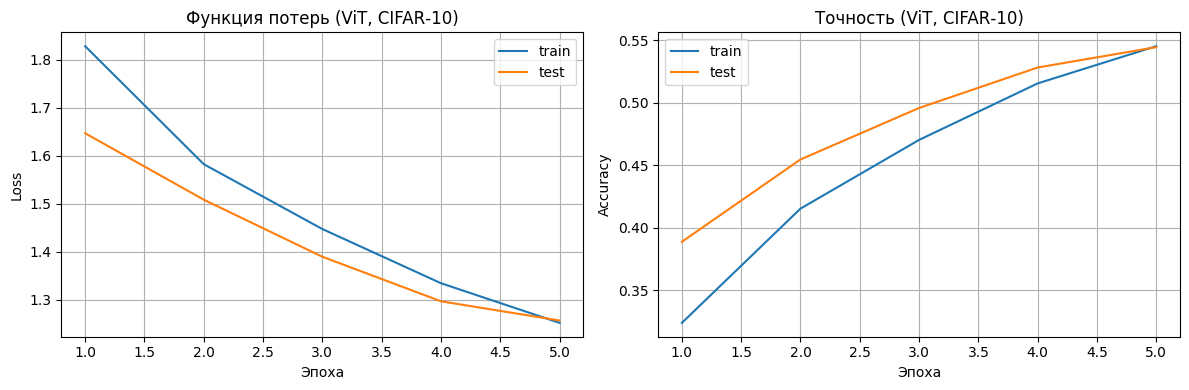

In [8]:
num_epochs = 5  # Начните с 5, для финального отчета можно увеличить до 10-15

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

# Отрисовка графиков (аналогично Лаб 8)
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (ViT, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (ViT, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ кривых обучения в сравнении с CNN

Опишите в 6–8 предложениях:

- Какую точность выдал базовый ViT за 5 эпох? Сравните эту цифру с точностью вашей CNN из Лабораторной работы 8 на том же этапе обучения.
- Заметно ли сильное переобучение (overfitting) у Трансформера?
- Почему обучение ViT "с нуля" на 50 000 картинок часто проигрывает классической CNN?

In [9]:
training_analysis = """
За 5 эпох базовый ViT достиг test_acc=0.544. В лабораторной 8 CNN на тех же
5 эпохах давала около 0.70-0.75 - ViT заметно отстаёт.

Переобучения почти нет - train и test кривые идут очень близко, к 5-й эпохе
практически совпадают (train=0.545, test=0.544). Это нетипично - обычно
трансформеры переобучаются быстро, но здесь модель просто ещё не успела
выучить данные за 5 эпох.

Интересно что на 1-й эпохе test_acc выше train_acc (0.389 vs 0.324) - модель
лучше работает на тесте чем на трейне в начале. Это из-за того что при
оценке dropout отключается.

ViT проигрывает CNN потому что у CNN встроено индуктивное смещение -
локальность и инвариантность к сдвигу. ViT должен выучить эти свойства сам
из данных, а 50000 картинок для этого мало. CNN с первой эпохи уже ищет
правильные локальные признаки, ViT только начинает понимать структуру патчей.
"""
print(training_analysis)


За 5 эпох базовый ViT достиг test_acc=0.544. В лабораторной 8 CNN на тех же
5 эпохах давала около 0.70-0.75 - ViT заметно отстаёт.

Переобучения почти нет - train и test кривые идут очень близко, к 5-й эпохе
практически совпадают (train=0.545, test=0.544). Это нетипично - обычно
трансформеры переобучаются быстро, но здесь модель просто ещё не успела
выучить данные за 5 эпох.

Интересно что на 1-й эпохе test_acc выше train_acc (0.389 vs 0.324) - модель
лучше работает на тесте чем на трейне в начале. Это из-за того что при
оценке dropout отключается.

ViT проигрывает CNN потому что у CNN встроено индуктивное смещение -
локальность и инвариантность к сдвигу. ViT должен выучить эти свойства сам
из данных, а 50000 картинок для этого мало. CNN с первой эпохи уже ищет
правильные локальные признаки, ViT только начинает понимать структуру патчей.



## 7. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны:

1. Изменить размер патча: попробуйте `patch_size = 4` (64 токена) и `patch_size = 16` (4 токена). Как размер патча влияет на точность и время обучения одной эпохи?
2. Попробовать сделать сеть глубже (`depth = 4` или `6`) и шире (`embed_dim = 128`).
3. (Опционально) Добавить аугментации данных (RandomCrop, RandomHorizontalFlip) в `transform` при загрузке `train_dataset`. Трансформеры сильно зависят от объема данных, поэтому аугментация для них критически важна.

Сравните **минимум два** варианта архитектуры ViT.

[patch4_d96_l3] Эпоха 1/5 | train_acc=0.3554, test_acc=0.4505 | время=429с


[patch4_d96_l3] Эпоха 2/5 | train_acc=0.4935, test_acc=0.5284 | время=431с


[patch4_d96_l3] Эпоха 3/5 | train_acc=0.5451, test_acc=0.5568 | время=429с


[patch4_d96_l3] Эпоха 4/5 | train_acc=0.5781, test_acc=0.5834 | время=429с


[patch4_d96_l3] Эпоха 5/5 | train_acc=0.6059, test_acc=0.6143 | время=428с
[patch4_d96_l3] Итого: 2145с, финальный test_acc=0.6143



...

[aug_patch8_d96_l3] Эпоха 1/5 | train_acc=0.2880, test_acc=0.3686 | время=119с


[aug_patch8_d96_l3] Эпоха 2/5 | train_acc=0.3733, test_acc=0.4005 | время=119с


[aug_patch8_d96_l3] Эпоха 3/5 | train_acc=0.4150, test_acc=0.4368 | время=119с


[aug_patch8_d96_l3] Эпоха 4/5 | train_acc=0.4537, test_acc=0.4888 | время=119с


[aug_patch8_d96_l3] Эпоха 5/5 | train_acc=0.4792, test_acc=0.5091 | время=119с


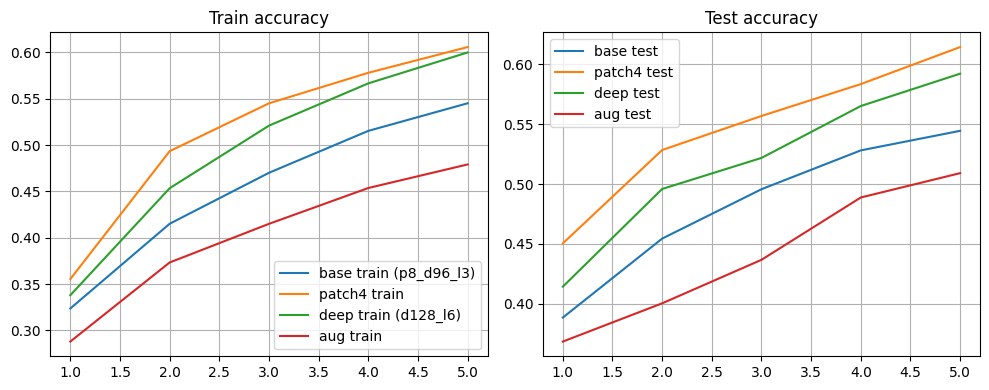

In [10]:
import time

def run_vit_experiment(patch_size, embed_dim, depth, heads, num_epochs=5, label=""):
    m = SimpleViT(patch_size=patch_size, embed_dim=embed_dim,
                  depth=depth, heads=heads).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=5e-4, weight_decay=1e-3)

    train_acc_hist, test_acc_hist = [], []
    total_time = 0

    for epoch in range(1, num_epochs + 1):
        start = time.time()
        tl, ta = train_one_epoch(m, train_loader, opt, criterion, device)
        vl, va = evaluate(m, test_loader, criterion, device)
        epoch_time = time.time() - start
        total_time += epoch_time
        train_acc_hist.append(ta)
        test_acc_hist.append(va)
        print(f"[{label}] Эпоха {epoch}/{num_epochs} | "
              f"train_acc={ta:.4f}, test_acc={va:.4f} | время={epoch_time:.0f}с")

    print(f"[{label}] Итого: {total_time:.0f}с, финальный test_acc={test_acc_hist[-1]:.4f}\n")
    return train_acc_hist, test_acc_hist

# Вариация 1 - маленький патч, больше токенов
ta1, ts1 = run_vit_experiment(patch_size=4, embed_dim=96, depth=3,
                               heads=4, label="patch4_d96_l3")

# Вариация 2 - глубокая и широкая модель
ta2, ts2 = run_vit_experiment(patch_size=8, embed_dim=128, depth=6,
                               heads=4, label="patch8_d128_l6")

# Вариация 3 - с аугментацией
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
train_aug = datasets.CIFAR10(root="./data", train=True, download=False, transform=transform_aug)
train_loader_aug = DataLoader(train_aug, batch_size=128, shuffle=True)

m_aug = SimpleViT(patch_size=8, embed_dim=96, depth=3, heads=4).to(device)
opt_aug = torch.optim.AdamW(m_aug.parameters(), lr=5e-4, weight_decay=1e-3)
ta3, ts3 = [], []
for epoch in range(1, 6):
    start = time.time()
    tl, ta = train_one_epoch(m_aug, train_loader_aug, opt_aug, criterion, device)
    vl, va = evaluate(m_aug, test_loader, criterion, device)
    ta3.append(ta); ts3.append(va)
    print(f"[aug_patch8_d96_l3] Эпоха {epoch}/5 | train_acc={ta:.4f}, test_acc={va:.4f} | время={time.time()-start:.0f}с")

# Сравнение всех вариантов
epochs_arr = np.arange(1, 6)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_arr, history["train_acc"], label="base train (p8_d96_l3)")
plt.plot(epochs_arr, ta1, label="patch4 train")
plt.plot(epochs_arr, ta2, label="deep train (d128_l6)")
plt.plot(epochs_arr, ta3, label="aug train")
plt.title("Train accuracy"); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_arr, history["test_acc"], label="base test")
plt.plot(epochs_arr, ts1, label="patch4 test")
plt.plot(epochs_arr, ts2, label="deep test")
plt.plot(epochs_arr, ts3, label="aug test")
plt.title("Test accuracy"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

## 8. Итоговые выводы по лабораторной

В конце опишите:

- Какой вариант гиперпараметров ViT (`patch_size`, `depth`, `embed_dim`) оказался самым удачным?
- Кто победил в итоге: CNN из Лабораторной 8 или ViT из Лабораторной 16 при обучении с нуля на CIFAR-10?
- В каких реальных задачах (и при каких объемах данных) вы бы стали применять Vision Transformer, а когда отдали бы предпочтение CNN?


In [11]:
final_summary = """
Лучшим вариантом оказался patch_size=4 с depth=3 и embed_dim=96 -
test_acc=0.614 за 5 эпох. Маленький патч даёт 64 токена вместо 16 и
модель видит намного больше деталей. Но цена - 428с на эпоху против 119с
у базового варианта, то есть в 3.5 раза медленнее.

Глубокая модель (depth=6, embed_dim=128) дала test_acc=0.592 - хуже чем
patch4, но быстрее (293с/эпоху). Увеличение глубины помогло меньше чем
уменьшение патча.

Аугментация показала худший результат за 5 эпох - test_acc=0.509. Это
ожидаемо: аугментация усложняет задачу и требует больше эпох чтобы
окупиться. На 20-30 эпохах она бы скорее всего вышла вперёд.

CNN из лабораторной 8 победила - она давала 0.70+ за те же 5 эпох против
0.61 у лучшего ViT. Индуктивное смещение CNN работает именно на таких
маленьких датасетах.

ViT стоит применять когда есть много данных (от 1 млн изображений) или
предобученная модель. CNN предпочтительнее для небольших датасетов,
встроенных систем где важна скорость, и медицинских изображений где
локальные признаки критичны.
"""
print(final_summary)


Лучшим вариантом оказался patch_size=4 с depth=3 и embed_dim=96 -
test_acc=0.614 за 5 эпох. Маленький патч даёт 64 токена вместо 16 и
модель видит намного больше деталей. Но цена - 428с на эпоху против 119с
у базового варианта, то есть в 3.5 раза медленнее.

Глубокая модель (depth=6, embed_dim=128) дала test_acc=0.592 - хуже чем
patch4, но быстрее (293с/эпоху). Увеличение глубины помогло меньше чем
уменьшение патча.

Аугментация показала худший результат за 5 эпох - test_acc=0.509. Это
ожидаемо: аугментация усложняет задачу и требует больше эпох чтобы
окупиться. На 20-30 эпохах она бы скорее всего вышла вперёд.

CNN из лабораторной 8 победила - она давала 0.70+ за те же 5 эпох против
0.61 у лучшего ViT. Индуктивное смещение CNN работает именно на таких
маленьких датасетах.

ViT стоит применять когда есть много данных (от 1 млн изображений) или
предобученная модель. CNN предпочтительнее для небольших датасетов,
встроенных систем где важна скорость, и медицинских изображений где
локальн